### L1 model training

Let's train a model using our baseline setup *with L1 regulization*. My network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats
from mlp.penalties import L1Penalty

# Set matplotlib style to ggplot for consistent gray background
plt.style.use('ggplot')

In [2]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [3]:
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

error =  CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

In [4]:
# Create model with three hidden layers and L1 penalties on weights and biases
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=L1Penalty(0.001), biases_penalty=L1Penalty(0.001)) # output layer
])


# stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
#     model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)


#### L1 and L2 Penalities

In [5]:
import pandas as pd
# Get dropout stats
L1L2_data = pd.read_csv('/Users/hallaei/UoE/mlp/mlpractical/data/regularization_experiments.csv')
L1L2_data = L1L2_data[L1L2_data['Model'].isin(['L1 penalty', 'L2 penalty'])]
[['Hyperparameter_Value', 'Validation_Accuracy', 'Train_Error', 'Validation_Error']]

[['Hyperparameter_Value',
  'Validation_Accuracy',
  'Train_Error',
  'Validation_Error']]

In [6]:
# Calculate error gap
L1L2_data['Error_Gap'] = L1L2_data['Validation_Error'] - L1L2_data['Train_Error']
L1L2_data.head(20)

,Model,Hyperparameter_Value,Validation_Accuracy,Train_Error,Validation_Error,Error_Gap
5,L1 penalty,5e-4,0.7950,0.642,0.658,0.016
6,L1 penalty,1e-3,0.7330,0.883,0.894,0.011
7,L1 penalty,5e-3,0.0241,3.850,3.850,0.000
8,L1 penalty,5e-2,0.0220,3.850,3.850,0.000
9,L2 penalty,5e-4,0.8510,0.306,0.460,0.154
10,L2 penalty,1e-3,0.8490,0.356,0.453,0.097
11,L2 penalty,5e-3,0.8130,0.586,0.607,0.021
12,L2 penalty,5e-2,0.3920,2.258,2.256,-0.002


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

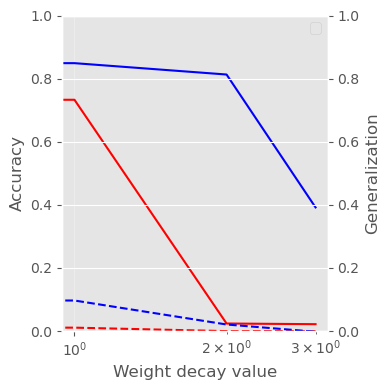

In [7]:
import matplotlib.pyplot as plt

# Plotting the Validation Accuracy and Generalisation Gap (difference between validation and training error) for each of the experiment results varying the Dropout inclusion rate

L1L2_plot = plt.figure(figsize=(4,4))
ax_L1L2_left = L1L2_plot.add_subplot(111)
ax_L1L2_right = ax_L1L2_left.twinx()

L1_plot_data = L1L2_data[L1L2_data['Model'] == 'L1 penalty'].copy()
L2_plot_data = L1L2_data[L1L2_data['Model'] == 'L2 penalty'].copy()

# Convert string columns to numeric to avoid categorical units warning
# L1_plot_data['Hyperparameter_Value'] = pd.to_numeric(L1_plot_data['Hyperparameter_Value'])
# L2_plot_data['Hyperparameter_Value'] = pd.to_numeric(L2_plot_data['Hyperparameter_Value'])

# Plot validation accuracy on the left y-axis
line_acc_l1 = ax_L1L2_left.plot(L1_plot_data['Hyperparameter_Value'], L1_plot_data['Validation_Accuracy'], label='L1 Val. Acc.', color='red')
line_gap_l1 = ax_L1L2_right.plot(L1_plot_data['Hyperparameter_Value'], L1_plot_data['Error_Gap'], label='L1 Gap', linestyle='dashed', color='red')

line_acc_l2 = ax_L1L2_left.plot(L2_plot_data['Hyperparameter_Value'], L2_plot_data['Validation_Accuracy'], label='L2 Val. Acc.', color='blue')
line_gap_l2 = ax_L1L2_right.plot(L2_plot_data['Hyperparameter_Value'], L2_plot_data['Error_Gap'], label='L2 Gap', linestyle='dashed', color='blue')
    

ax_L1L2_left.set_xlabel('Weight decay value')
ax_L1L2_left.set_ylabel('Accuracy')
ax_L1L2_left.set_ylim(0.0, 1.0)
ax_L1L2_left.set_xscale('log')

ax_L1L2_right.set_ylabel('Generalization')
ax_L1L2_right.set_ylim(0.0, 1.0)

lines = [line_acc_l1, line_gap_l1, line_acc_l2, line_gap_l2]
labels = [l[0].get_label() for l in lines]
ax_L1L2_left.legend(lines, labels, loc=0)
ax_L1L2_left.grid(True, alpha=0.3)

L1L2_plot.tight_layout()
L1L2_plot.savefig('/Users/hallaei/UoE/mlp/mlpractical/report/figures/wd_plot.png')